In [1]:
#%config InlineBackend.figure_formats=['svg']
from os import listdir
import numpy as np

from ExistingAlgorithms.Plot import plot_1D, plot_traces

from AutoencoderAPI.utils.compare import compare
from AutoencoderAPI.utils.clustering.kernelDensity import kernel_density
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

from ExistingAlgorithms.MaxValue import max_value
from ExistingAlgorithms.Area import area
from ExistingAlgorithms.SklearnAvailable import dimension_reduction

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

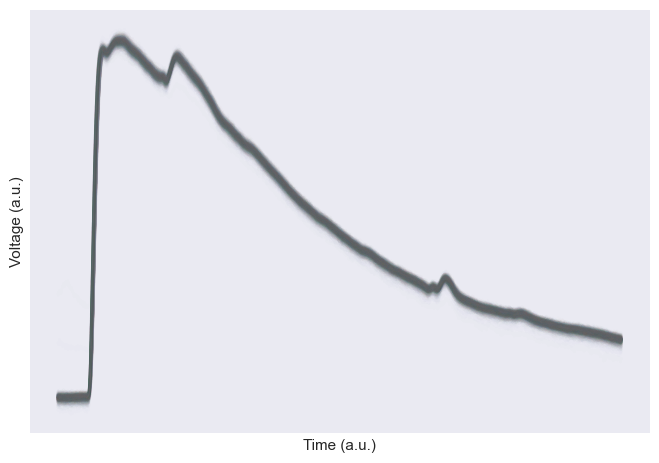

In [2]:
signal_size = 30_000 #250
#path_test = 'Datasets/NIST (250) test/'
#path_train = 'Datasets/NIST (250) train/'

path_test = r'C:\Users\dalbe\Documents\Datasets\SNSPD\Paderborn\data/'

X_test = np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size)[::20, 3000:8_000] for fileName in listdir(path_test)[::5]]) #fromfile(),dtype=np.float16)
X_test = X_test.astype("double")
X_test = -1*(X_test - np.mean(X_test))/np.var(X_test)
X_test = X_test[np.max(X_test, axis=1) > 0.0001]
X_test = X_test[np.argmax(X_test, axis=1) < 1000]

#X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
#X_train = X_train.astype("double")[::2]

#X = np.concatenate((X_test,X_train))
X_train = X_test
plot_traces(np.copy(X_test))

### Max Value

In [10]:
X_i_MAX, X_r_MAX, X_l_MAX = max_value(np.copy(X_test), filter=True)

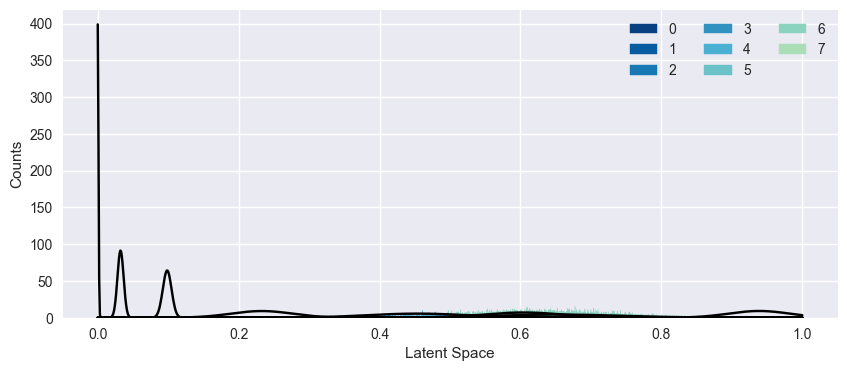

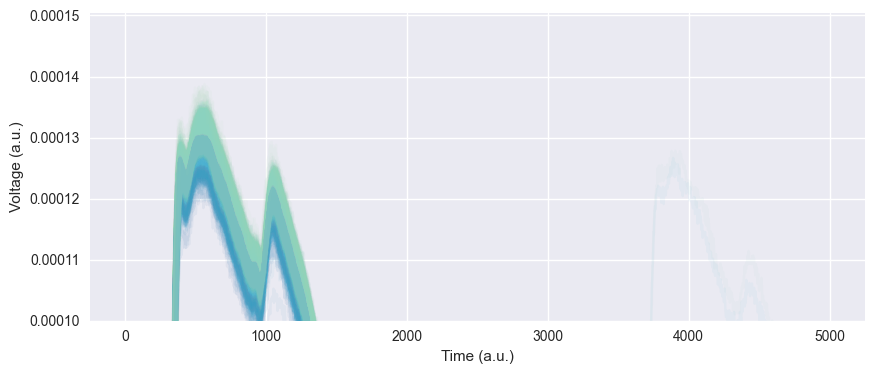

c:\Users\dalbe\anaconda3\envs\ML\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\dalbe\anaconda3\envs\ML\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


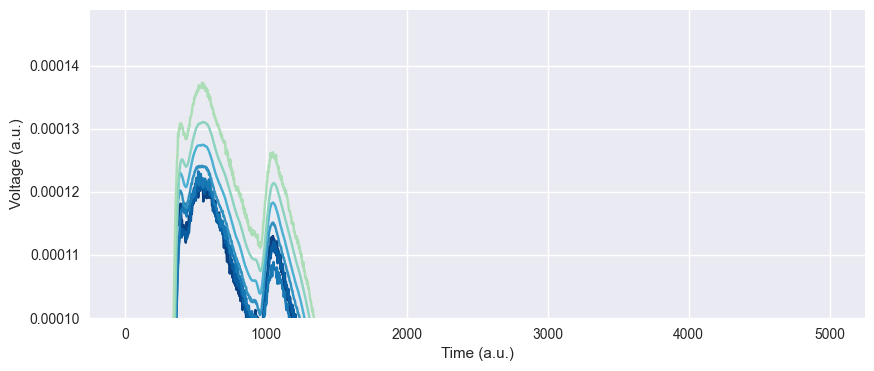

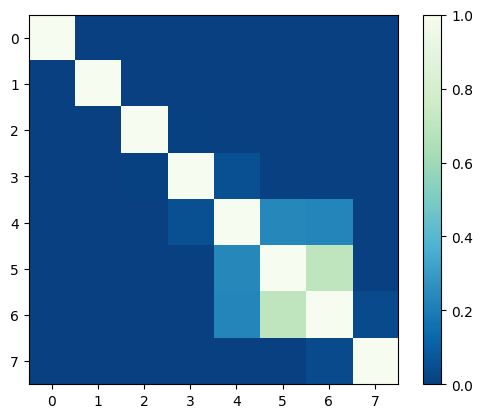

In [11]:
kd = density_gaussianMixture(X_l_MAX, 
                                bw = [0.01], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()

### Area

In [5]:
X_i_AREA, X_r_AREA, X_l_AREA = area(np.copy(X_test), filter=True, threshold_cst=0)

<Figure size 1000x400 with 0 Axes>

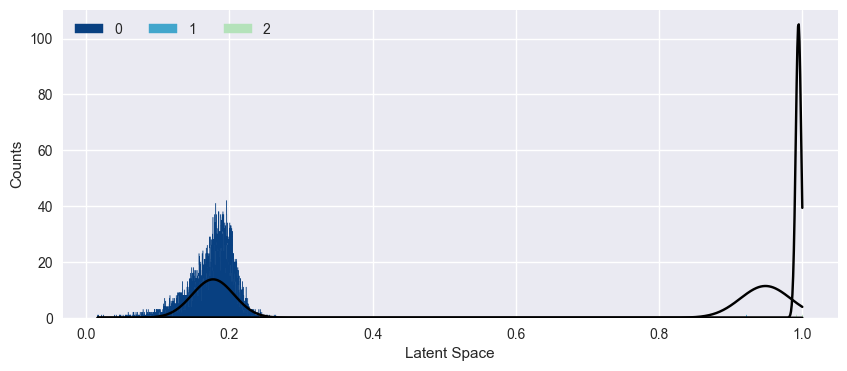

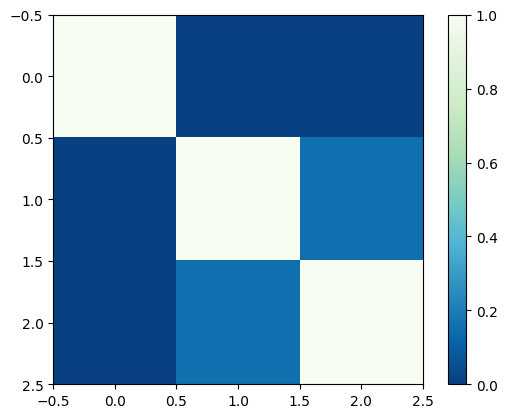

In [7]:
kd = density_gaussianMixture(X_l_AREA, 
                                bw = [0.01], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 1)
#kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()

### Principal Component Analysis (PCA)

In [19]:
X_i_PCA, X_r_PCA, X_l_PCA = dimension_reduction(np.copy(X_train),np.copy(X_test),PCA,n_components=1)

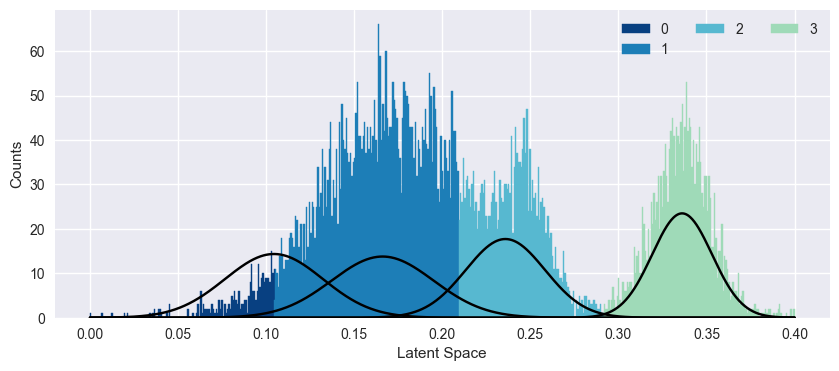

IndexError: boolean index did not match indexed array along dimension 1; dimension is 5000 but corresponding boolean dimension is 1

In [20]:
kd = density_gaussianMixture(X_l_PCA[X_l_PCA<0.4], 
                                bw = [0.008], 
                                bins_plot = 500,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test)[X_l_PCA<0.4])
kd.plot_traces_average(np.copy(X_test)[X_l_PCA<0.4])
kd.plot_cross_talk()

### Kernel PCA (Polynomial)

In [56]:
X_i_KPCA_P, X_r_KPCA_P, X_l_KPCA_P = dimension_reduction(np.copy(X_train),np.copy(X_test),KernelPCA,n_components=1, kernel="poly", fit_inverse_transform=True)

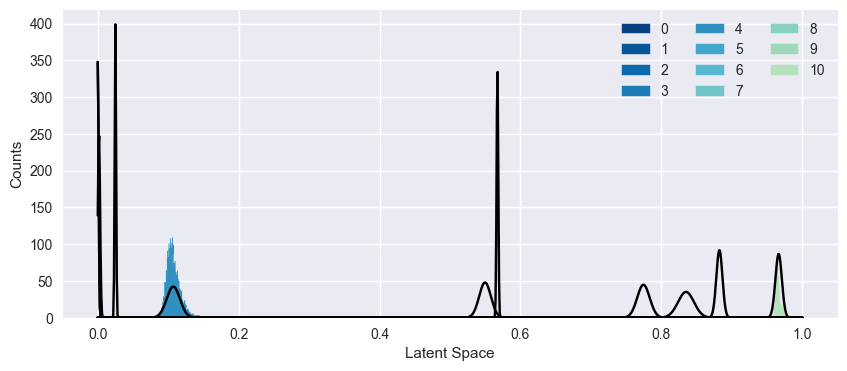

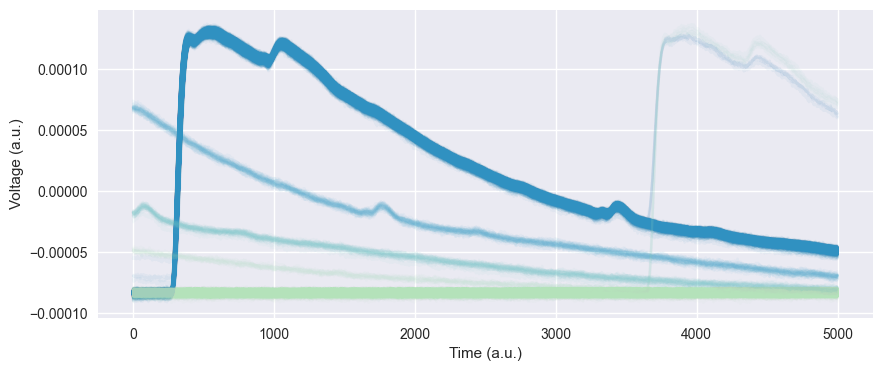

c:\Users\dalbe\Documents\Msc Engineering Physics\Single-Photon-Detection\src\AutoencoderAPI\utils\clustering\densityGaussianMixture.py:115: RuntimeWarning: invalid value encountered in divide
  c = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log(sig1/sig2))))/(sig1**2 - sig2**2)


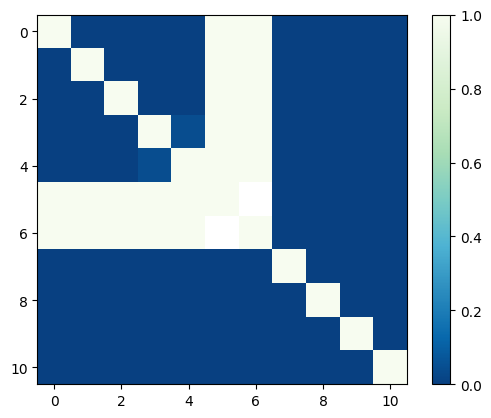

In [57]:
kd = density_gaussianMixture(X_l_KPCA_P, 
                                bw = [0.008], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()

### Kernel PCA (Radial basis function)

In [58]:
X_i_KPCA_RBF, X_r_KPCA_RBF, X_l_KPCA_RBF = dimension_reduction(np.copy(X_train),np.copy(X_test),KernelPCA,n_components=1,kernel="rbf",gamma=0.02, fit_inverse_transform=True)

In [59]:
kd = density_gaussianMixture(X_l_KPCA_RBF, 
                                bw = [0.008], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()

### Kernel PCA (Sigmoid)

In [ ]:
X_i_KPCA_S, X_r_KPCA_S, X_l_KPCA_S = dimension_reduction(np.copy(X_train),np.copy(X_test),KernelPCA,n_components=1,kernel="sigmoid",gamma=0.02, fit_inverse_transform=True)

In [ ]:
kd = density_gaussianMixture(X_l_KPCA_S, 
                                bw = [0.01], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Kernel PCA (Cosine)

In [ ]:
X_i_KPCA_C, X_r_KPCA_C, X_l_KPCA_C = dimension_reduction(np.copy(X_train),np.copy(X_test),KernelPCA,n_components=1,kernel="cosine",gamma=0.02, fit_inverse_transform=True)

In [ ]:
kd = density_gaussianMixture(X_l_KPCA_C, 
                                bw = [0.01], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### t-distributed Stochastic Neighbor Embedding (t-SNE)

In [14]:
X_i_TSNE, X_r_TSNE, X_l_TSNE = dimension_reduction(np.copy(X_train),np.copy(X_test),TSNE,n_components=1, perplexity=5000)

'TSNE' object has no attribute 'transform'


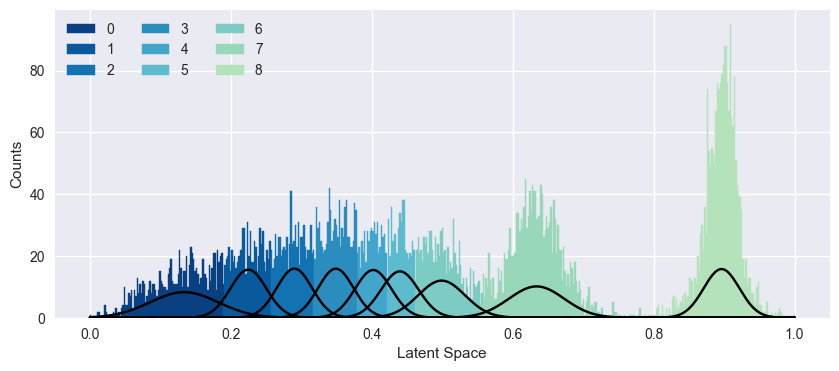

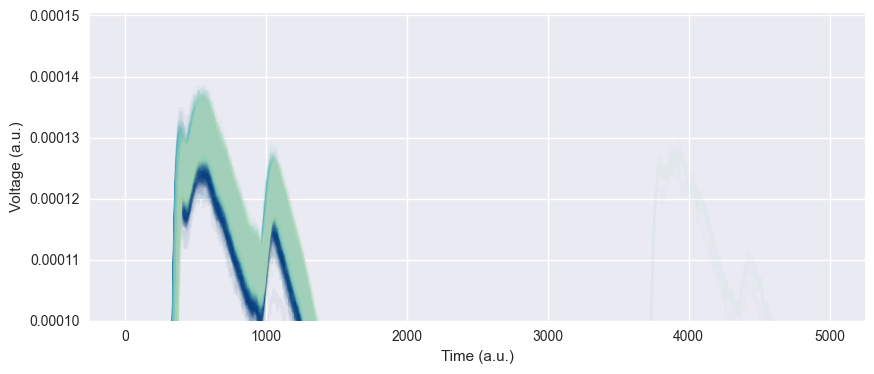

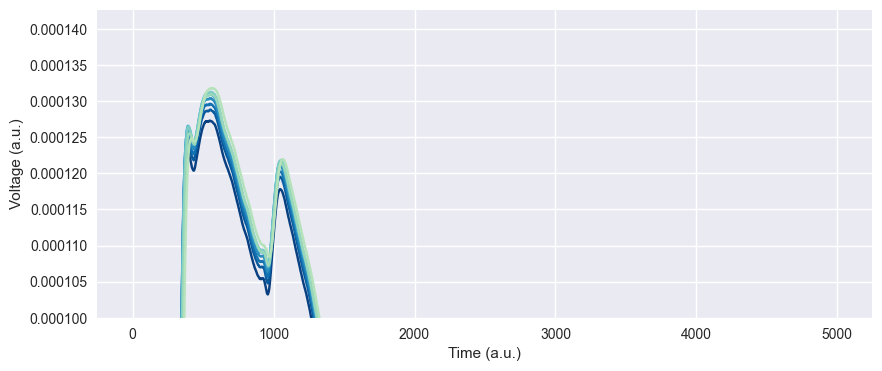

In [15]:
kd = density_gaussianMixture(X_l_TSNE, 
                                bw = [0.01], 
                                bins_plot = 500,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))

### Spectral Embedding 

In [ ]:
#X_i_SE, X_r_SE, X_l_SE = dimension_reduction(np.copy(X),SpectralEmbedding,n_components=1)
#plot_1D(X_l_SE)

### Non-Negative Matrix Factorization (NMF)

In [ ]:
X_i_NMF, X_r_NMF, X_l_NMF = dimension_reduction(np.copy(X_train),np.copy(X_test),NMF,n_components=1,alpha_W=0.1,random_state=42)

In [ ]:
kd = density_gaussianMixture(X_l_NMF, 
                                bw = [0.01], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Isomap

In [ ]:
X_i_ISO, X_r_ISO, X_l_ISO = dimension_reduction(np.copy(X_train),np.copy(X_test),Isomap,n_neighbors=20, n_components=1, eigen_solver="arpack")

In [ ]:
kd = density_gaussianMixture(X_l_ISO, 
                                bw = [0.01], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Autoencoder



In [ ]:
X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(np.copy(X_test), 'Test/test NIST (250)/fold 0/', filter=False, flip=True)

In [ ]:
kd = density_gaussianMixture(X_l_AUTO, 
                                bw = [0.008], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))

In [ ]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X_test), 'Test/test NIST (250)/fold 0/', filter=True, flip=True)

In [ ]:
kd = density_gaussianMixture(X_l_AUTOF, 
                                bw = [0.008], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))

In [ ]:
i = [X_i_MAX, X_i_AREA, X_i_PCA, X_i_KPCA_P, 
     X_i_KPCA_RBF, X_i_KPCA_S, X_i_KPCA_C, X_i_NMF, 
     X_i_TSNE, X_i_ISO, 
      X_i_AUTO, X_i_AUTOF]
l = [X_l_MAX, X_l_AREA, X_l_PCA, X_l_KPCA_P, 
     X_l_KPCA_RBF, X_l_KPCA_S, X_l_KPCA_C, X_l_NMF, 
     X_l_TSNE, X_l_ISO, 
      X_l_AUTO, X_l_AUTOF]
r = [X_r_MAX, X_r_AREA, X_r_PCA, X_r_KPCA_P, 
     X_r_KPCA_RBF, X_r_KPCA_S, X_r_KPCA_C, X_r_NMF,
     X_r_TSNE, X_r_ISO, 
      X_r_AUTO, X_r_AUTOF]
methods = ['Max', 'Area', 'PCA', 'K-PCA (Polynomial)', 
           'K-PCA (RBF)', 'K-PCA (Sigmoid)', 
           'K-PCA (Cosine)', 'NMF', 't-SNE', 'Isomap',
           'Autoencoder', 'Autoencoder\nFiltered']
bw = [0.009, 0.009, 0.009, 0.009,
      0.009, 0.009, 0.015, 0.007, 0.009, 0.007,
      0.009, 0.007]

#comp = compare(bw)
#comp.quality_metric_plot(i,r,l,methods, 40)